### Identify genes with highest contribution to fetal reactivation score

In [1]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import glob

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
plots_dir = "plots/"

In [4]:
def aggregate_gene_contributions(file_paths, fetal_gene_set, score_key='total_fetalization'):
    '''Loads multiple adata files, calculates gene correlations per file, and aggregates results with confidence intervals.'''
    
    all_correlations = []
    
    for path in file_paths:
        print(f"Processing: {path.split('/')[-1]}...")
        adata = sc.read_h5ad(path)
        
        # ensure we only test genes present in this specific section
        genes_to_test = [g for g in fetal_gene_set if g in adata.var_names]
        
        # calculate Spearman correlation for this section
        section_corrs = {}
        exp_data = adata[:, genes_to_test].to_df()
        score_data = adata.obs[score_key]
        
        for gene in genes_to_test:
            # avoid errors if a gene has zero variance in a specific section
            if exp_data[gene].std() == 0:
                section_corrs[gene] = np.nan
            else:
                coef, _ = stats.spearmanr(exp_data[gene], score_data)
                section_corrs[gene] = coef
        
        all_correlations.append(pd.Series(section_corrs, name=path))
        del adata

    # combine all correlations into a single df
    master_corr_df = pd.concat(all_correlations, axis=1)
    
    # calculate aggregate statistics
    summary = pd.DataFrame(index=master_corr_df.index)
    summary['mean_rho'] = master_corr_df.mean(axis=1)
    summary['std_err'] = master_corr_df.sem(axis=1)
    summary['n_sections'] = master_corr_df.notna().sum(axis=1)
    
    # calculate 95% CI for t-distribution
    ci_multiplier = stats.t.ppf(0.975, df=summary['n_sections'] - 1)
    summary['ci_lower'] = summary['mean_rho'] - (ci_multiplier * summary['std_err'])
    summary['ci_upper'] = summary['mean_rho'] + (ci_multiplier * summary['std_err'])
    
    # perform a one-sample t-test, against the null that mean correlation across sections is 0
    p_values = []
    for gene in summary.index:
        # drop na for the specific gene across sections
        rhos = master_corr_df.loc[gene].dropna()
        if len(rhos) > 1:
            _, p = stats.ttest_1samp(rhos, 0)
            p_values.append(p)
        else:
            p_values.append(1.0)
            
    summary['p_value'] = p_values
    summary['adj_p_value'] = multipletests(p_values, method='fdr_bh')[1]
    
    return summary.sort_values('mean_rho', ascending=False)

In [5]:
cell_types = ["Cardiomyocyte", "Endothelial", "Fibroblast", "Myeloid", "Lymphoid", "Neuronal", "Pericyte", "vSMC"]

In [6]:
res_df = pd.read_csv("Kuppe_Moran_I_results.csv", index_col = 0)
high_fetalization_samples = res_df[res_df['prop_fetalization_spots'] > 5]['sample']

In [7]:
diseased_sections = ["adata_with_weighted_fetalization_scores/" + high_fetal + ".h5ad" for high_fetal in high_fetalization_samples]

In [8]:
fetal_genes = pd.read_csv("../../../../v2_aggregated_analysis/pseudobulked_analysis/intersection_analysis/03E_most_shared_UP_fetalization_genes.csv", index_col =0)['gene']

In [9]:
gene_contributions = aggregate_gene_contributions(diseased_sections, fetal_genes, score_key = 'total_non_fetal_disease')

Processing: Visium_IZ_P10.h5ad...
Processing: Visium_IZ_P15.h5ad...
Processing: Visium_GT_IZ_P13.h5ad...
Processing: Visium_FZ_P20.h5ad...
Processing: Visium_RZ_FZ_P5.h5ad...
Processing: Visium_FZ_P18.h5ad...
Processing: Visium_RZ_GT_P2.h5ad...
Processing: Visium_IZ_BZ_P2.h5ad...
Processing: Visium_GT_IZ_P9.h5ad...
Processing: Visium_FZ_GT_P19.h5ad...
Processing: Visium_FZ_P14.h5ad...
Processing: Visium_GT_IZ_P9_rep2.h5ad...
Processing: Visium_IZ_P16.h5ad...
Processing: Visium_FZ_GT_P4.h5ad...
Processing: Visium_GT_IZ_P15.h5ad...


In [10]:
#print(gene_contributions.head(20))

In [24]:
def plot_gene_contributions(df, top_n=25, figsize_tuple=(8,5)):
    '''Plots the top gene contributors with confidence intervals.'''
    
    # sort and take the top N genes by mean correlation
    # focus on the strongest positive correlates for fetalization
    plot_df = df.sort_values('mean_rho', ascending=False).head(top_n).copy()
    
    # create the figure
    plt.figure(figsize=figsize_tuple)
    sns.set_style("whitegrid")
    
    error_low = plot_df['mean_rho'] - plot_df['ci_lower']
    error_high = plot_df['ci_upper'] - plot_df['mean_rho']
    
    # Plot bars
    bars = plt.bar(plot_df.index, plot_df['mean_rho'], 
                    #yerr=[error_low, error_high],
                    color='salmon', capsize=5, alpha=0.9,
                    edgecolor='black', linewidth=0.5)
    # styling
    plt.axhline(0, color='black', linestyle='-', linewidth=1)
    plt.ylabel('Mean Spearman Correlation ($\\rho$)', )
    plt.xlabel('Genes')
    plt.xticks(size = 10, rotation = 60)
    plt.title(f'Top {top_n} Fetalization Gene Contributors\n(Aggregated across {int(plot_df["n_sections"].max())} sections)', 
              pad=20, fontsize=16)

    plt.tight_layout()
    
    return plt

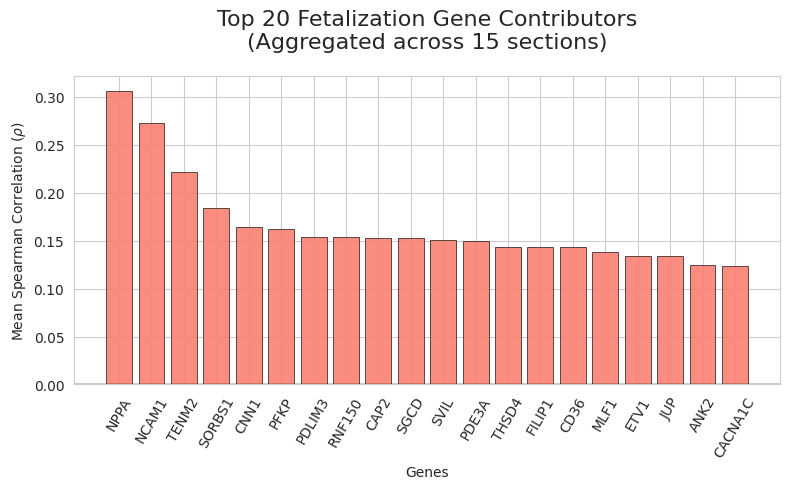

In [25]:
# produce plot 
correlation_plot = plot_gene_contributions(gene_contributions, top_n=20)
plt.savefig(plots_dir + "fetalization_gene_correlations.pdf")

In [20]:
#gene_contributions.index[0:100]